# 1. Import bazy danych oraz podstawowa konfiguracja

In [135]:
import pandas as pd

In [136]:
df = pd.read_csv("Car_Insurance_Claim.csv").dropna(subset="ANNUAL_MILEAGE")
df.drop(["RACE", "POSTAL_CODE", "VEHICLE_TYPE", "ID"], axis=1, inplace=True)
df.head()

,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,12000.0,0,0,0,0.0
1,16-25,male,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,16000.0,0,0,0,1.0
2,16-25,female,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,11000.0,0,0,0,0.0
3,16-25,male,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,11000.0,0,0,0,0.0
4,26-39,male,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,12000.0,2,0,1,1.0


# 2. Edytowanie zmiennych - przygotowanie dla modelu predykcyjnego

In [137]:
def wiek(wiek_str):
    if wiek_str == "16-25":
        return 21
    elif wiek_str == "26-39":
        return 33
    elif wiek_str == "40-64":
        return 52
    elif wiek_str == "65+":
        return 70

df["AGE"] = df["AGE"].apply(wiek)

In [138]:
def doswiadczenie(dosw_str):
    if dosw_str == "0-9y":
        return 5
    elif dosw_str == "10-19y":
        return 15
    elif dosw_str == "20-29y":
        return 25
    elif dosw_str == "30y+":
        return 35

df["DRIVING_EXPERIENCE"] = df["DRIVING_EXPERIENCE"].apply(doswiadczenie)

In [139]:
def edukacja(edu_str):
    if edu_str == "none":
        return 1
    elif edu_str == "high school":
        return 2
    elif edu_str == "university":
        return 3

df["EDUCATION"] = df["EDUCATION"].apply(edukacja)

In [140]:
def plec(plec_str):
    if plec_str == "male":
        return 0
    elif plec_str == "female":
        return 1

df["GENDER"] = df["GENDER"].apply(plec)

In [141]:
def przychod(przy_str):
    if przy_str == "poverty":
        return 1
    elif przy_str == "working class":
        return 2
    elif przy_str == "middle class":
        return 3
    elif przy_str == "upper class":
        return 4

df["INCOME"] = df["INCOME"].apply(przychod)

In [142]:
def wiek_auta(wa_str):
    if wa_str == "before 2015":
        return 0
    elif wa_str == "after 2015":
        return 1

df["VEHICLE_YEAR"] = df["VEHICLE_YEAR"].apply(wiek_auta)

# 3. Dodanie zmiennych, które dzielą liczbę popełnionych wykroczeń danego typu przez lata doświadczenia

In [143]:
df["SPEEDING_VIOLATIONS_PER_YEAR"] = df["SPEEDING_VIOLATIONS"] / df["DRIVING_EXPERIENCE"]
df["PAST_ACCIDENTS_PER_YEAR"] = df["PAST_ACCIDENTS"] / df["DRIVING_EXPERIENCE"]
df["DUIS_PER_YEAR"] = df["DUIS"] / df["DRIVING_EXPERIENCE"]
df.head()

,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,SPEEDING_VIOLATIONS_PER_YEAR,PAST_ACCIDENTS_PER_YEAR,DUIS_PER_YEAR
0,70,1,5,2,4,0.629027,1.0,1,0.0,1.0,12000.0,0,0,0,0.0,0.000000,0.000000,0.0
1,21,0,5,1,1,0.357757,0.0,0,0.0,0.0,16000.0,0,0,0,1.0,0.000000,0.000000,0.0
2,21,1,5,2,2,0.493146,1.0,0,0.0,0.0,11000.0,0,0,0,0.0,0.000000,0.000000,0.0
3,21,0,5,3,2,0.206013,1.0,0,0.0,1.0,11000.0,0,0,0,0.0,0.000000,0.000000,0.0
4,33,0,15,1,2,0.388366,1.0,0,0.0,0.0,12000.0,2,0,1,1.0,0.133333,0.066667,0.0


# 4. Przeprowadzenie analizy danych

## a) Macierz korelacji

In [144]:
df.corr()

,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,SPEEDING_VIOLATIONS_PER_YEAR,PAST_ACCIDENTS_PER_YEAR,DUIS_PER_YEAR
AGE,1.000000,-0.007103,0.702483,0.255579,0.639390,0.488203,0.265692,0.231534,0.378736,0.379954,-0.274368,0.459667,0.283878,0.429072,-0.427021,0.340057,0.308941,0.186130
GENDER,-0.007103,1.000000,-0.008701,-0.081091,-0.027959,0.078427,-0.012305,-0.012464,-0.010267,0.000274,0.015845,-0.203578,-0.096611,-0.228696,-0.105643,-0.222795,-0.244620,-0.098639
DRIVING_EXPERIENCE,0.702483,-0.008701,1.000000,0.177011,0.456713,0.344671,0.202326,0.166363,0.265223,0.278600,-0.187520,0.639139,0.400547,0.603102,-0.495759,0.508279,0.468297,0.283970
EDUCATION,0.255579,-0.081091,0.177011,1.000000,0.567326,0.416363,0.236263,0.205473,0.197568,0.122594,-0.129150,0.138962,0.091875,0.125034,-0.187763,0.121052,0.098981,0.078028
INCOME,0.639390,-0.027959,0.456713,0.567326,1.000000,0.745151,0.423343,0.357014,0.394134,0.289959,-0.263135,0.310516,0.196348,0.285928,-0.417649,0.260308,0.229678,0.147981
CREDIT_SCORE,0.488203,0.078427,0.344671,0.416363,0.745151,1.000000,0.312995,0.266157,0.282555,0.221354,-0.174453,0.208433,0.127888,0.182408,-0.321436,0.169360,0.136965,0.093917
VEHICLE_OWNERSHIP,0.265692,-0.012305,0.202326,0.236263,0.423343,0.312995,1.000000,0.155296,0.176478,0.120432,-0.097433,0.134071,0.088053,0.119269,-0.385618,0.110016,0.091298,0.068612
VEHICLE_YEAR,0.231534,-0.012464,0.166363,0.205473,0.357014,0.266157,0.155296,1.000000,0.131883,0.107001,-0.077363,0.108341,0.051784,0.098375,-0.289614,0.086537,0.072201,0.028094
MARRIED,0.378736,-0.010267,0.265223,0.197568,0.394134,0.282555,0.176478,0.131883,1.000000,0.290714,-0.462193,0.218306,0.120351,0.210633,-0.256271,0.194579,0.180408,0.092231
CHILDREN,0.379954,0.000274,0.278600,0.122594,0.289959,0.221354,0.120432,0.107001,0.290714,1.000000,-0.447655,0.223971,0.116300,0.205087,-0.233549,0.200662,0.178620,0.088332


Największe korelacje z roszczeniami komunikacyjnymi mają wiek, doświadczenie, dochód, własność auta, wiek auta, zdolność kredytowa (jednak ten atrybut jest bardzo mocno skorelowany z dochodem, co sugeruje że wykresy będą bardzo podobne). Sprawdzę za pomocą wykresów jak wyglądają te korelacje, a także zobaczę jak dużo osób powoduje roszczenia komunikacyjne

## b) Wykres roszczeń komunikacyjnych

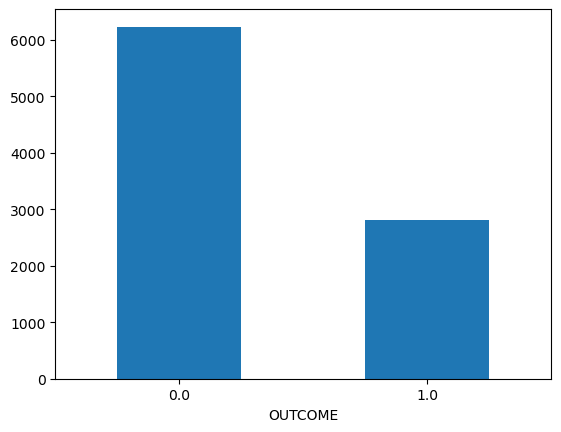

In [145]:
df["OUTCOME"].value_counts().plot.bar(rot=0);

## c) Zgłaszane roszczenia w zależności od wieku

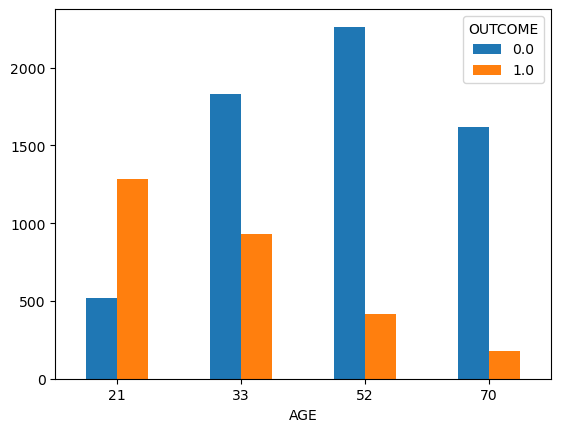

In [160]:
df.groupby(by="OUTCOME")["AGE"].value_counts().unstack(0).plot.bar(rot=0);

## d) Zgłaszane roszczenia w zależności od doświadczenia

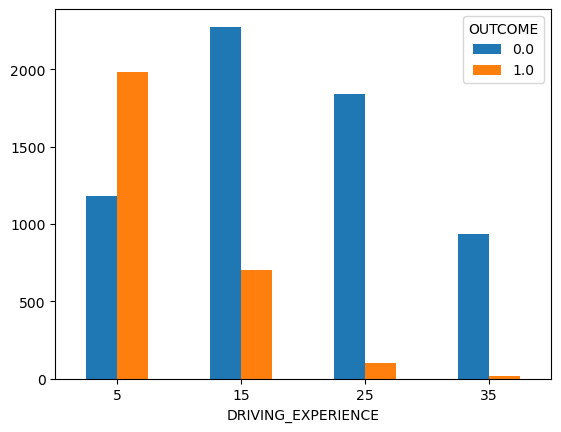

In [161]:
df.groupby(by="OUTCOME")["DRIVING_EXPERIENCE"].value_counts().unstack(0).plot.bar(rot=0);

## e) Zgłaszane roszczenia w zależności od posiadania auta

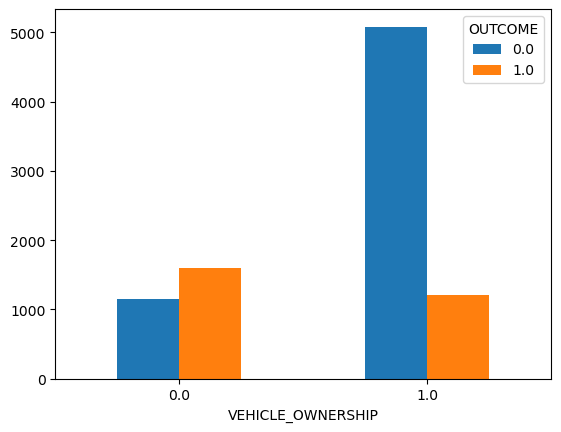

In [162]:
df.groupby(by="OUTCOME")["VEHICLE_OWNERSHIP"].value_counts().unstack(0).plot.bar(rot=0);

## f) Zgłaszane roszczenia w zależności od wieku auta

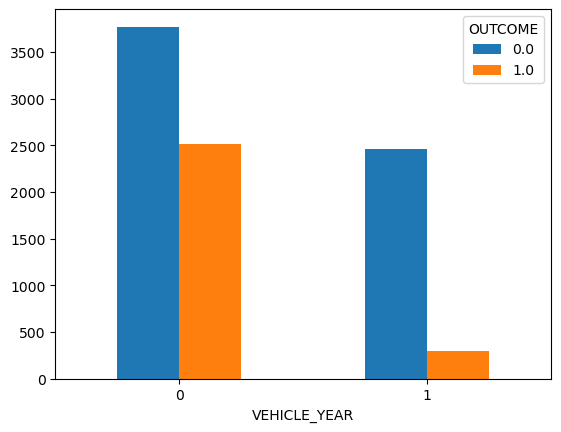

In [163]:
df.groupby(by="OUTCOME")["VEHICLE_YEAR"].value_counts().unstack(0).plot.bar(rot=0);

## g) Zgłaszanie roszczenia w zależności od dochodu

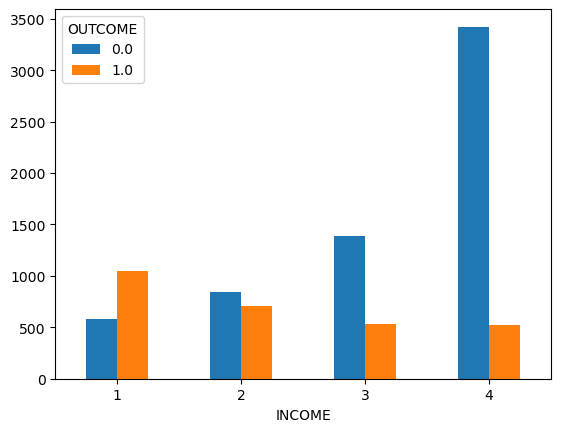

In [164]:
df.groupby(by="OUTCOME")["INCOME"].value_counts().unstack(0).plot.bar(rot=0);

## h) Analiza grupy największego ryzyka

Z poprzednich punktów analizy danych można zauważyć, że największymi grupami, które powodują roszczenia są:
- osoby bez dużego doświadczenia
- osoby bez własnego samochodu (w wyniku leasingu, albo używają auta które należy do kogoś z rodziny)
- osoby jeżdżące starym samochodem
- osoby mające niskie dochody

Sprawdzę czy taka zależność zachodzi także dla osób spełniających każde z tych czterech warunków

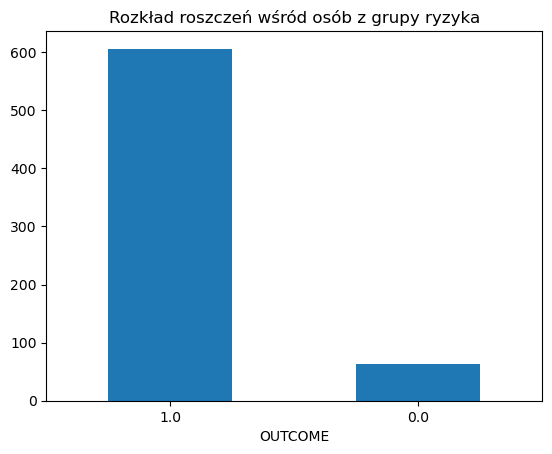

In [165]:
brak_doświadczenia = df["DRIVING_EXPERIENCE"] == 5
brak_własności = df["VEHICLE_OWNERSHIP"] == 0
stary_pojazd = df["VEHICLE_YEAR"] == 0
niskie_dochody = df["INCOME"] == 1

grupa_ryzyka = df.loc[brak_doświadczenia & brak_własności & stary_pojazd & niskie_dochody, ["OUTCOME", "SPEEDING_VIOLATIONS", "PAST_ACCIDENTS", "DUIS"]]
grupa_ryzyka["OUTCOME"].value_counts().plot.bar(title="Rozkład roszczeń wśród osób z grupy ryzyka", rot=0);

Udało mi się pokazać, że taki zestaw osób z bardzo dużym prawdopodobieństwem, będzie powodował roszczenia. Dalej sprawdzę jak dużo wykroczeń popełniała ta grupa ryzyka. Ta grupa to około 1/5 wszystkich przypadków roszczeń komunikacyjnych

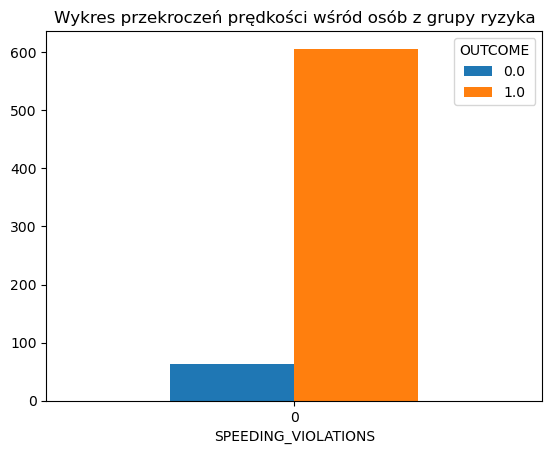

In [166]:
grupa_ryzyka.groupby(by="OUTCOME")["SPEEDING_VIOLATIONS"].value_counts().unstack(0).plot.bar(title="Wykres przekroczeń prędkości wśród osób z grupy ryzyka", rot=0);

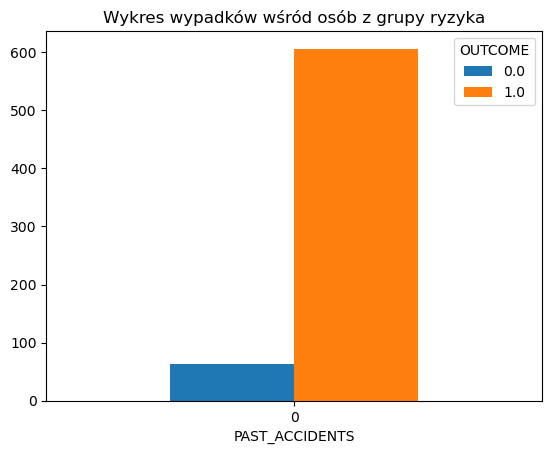

In [167]:
grupa_ryzyka.groupby(by="OUTCOME")["PAST_ACCIDENTS"].value_counts().unstack(0).plot.bar(title="Wykres wypadków wśród osób z grupy ryzyka", rot=0);

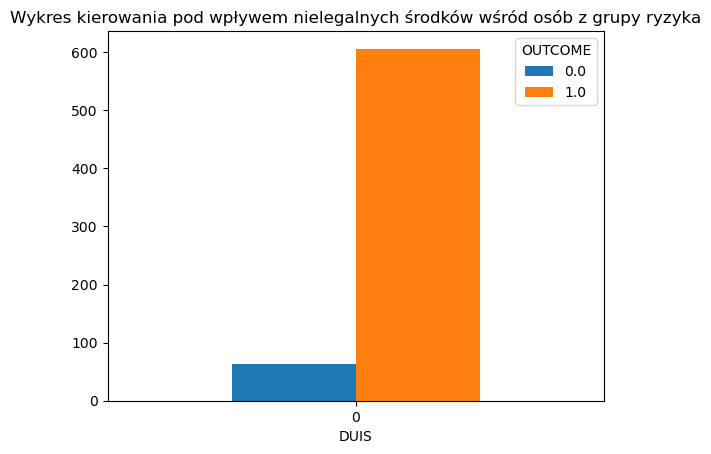

In [168]:
grupa_ryzyka.groupby(by="OUTCOME")["DUIS"].value_counts().unstack(0).plot.bar(title="Wykres kierowania pod wpływem nielegalnych środków wśród osób z grupy ryzyka", rot=0);

Analiza grupy największego ryzyka, pokazuje że przed ich pierwszą kolizją nie łamali wcześniej prawa. Jest to dosyć liczna grupa, więc utrudnione może być wysuwanie wniosków na podstawie liczby złamanych przepisów. Intuicyjnie mogłoby się wydawać że osoby z najmniejszym doświadczeniem będą najczęściej łamali prawo

# 5. Utworzenie modelu predykcyjnego i sprawdzenie jego dokładności

In [171]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop("OUTCOME", axis=1)
y = df["OUTCOME"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
przewidywania = model.predict(X_test)

In [172]:
macierz_pomylki = pd.crosstab(y_test, przewidywania, 
                         rownames=['Faktyczne'], 
                         colnames=['Przewidziane'], 
                         normalize='index')
print(macierz_pomylki)

Przewidziane         0         1
Faktyczne                       
0.0           0.875598  0.124402
1.0           0.309910  0.690090


# 6. Przeprowadzenie analizy modelu predykcyjnego - sprawdzenie jakie kolumny są najbardziej znaczące

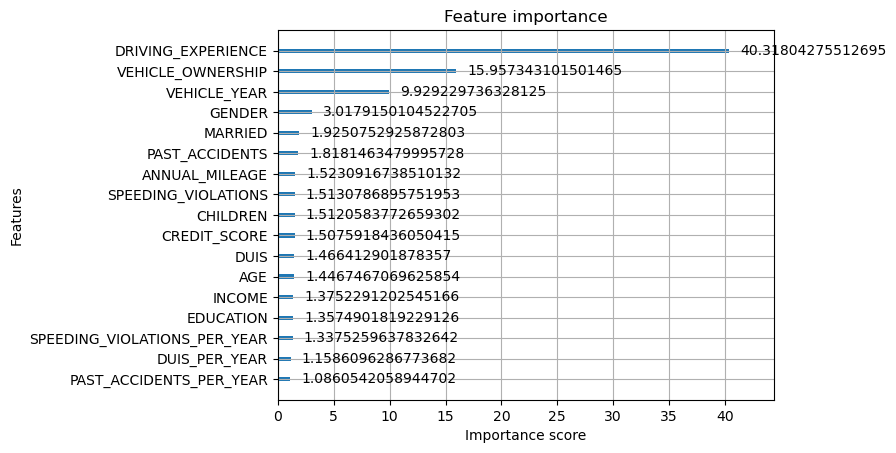

In [173]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, importance_type='gain', max_num_features=20)
plt.show()

# 7. Wnioski na podstawie modelu predykcyjnego i analizy danych:
- Model poprawnie identyfikuje klientów bez zgłoszonych szkód w 88% i tych z zgłoszonymi szkodami w 69%
- Najważniejsze 3 czynniki wpływające na dokładność modelu to: doświadczenie kierowcy, czy jest właścicielem auta oraz wiek auta. Pokrywa się to z wcześniej przeprowadzoną analizą.
- Ocenianie ryzyka na podstawie wcześniejszych naruszeń przepisów nie jest skuteczne. Jest to potwierdzenie wniosku, który został wysunięty na etapie analizy danych tego zbioru